In [4]:
import pickle
from typing import Callable, Optional
import json

import contextily as cx
import geopandas as gpd
import jenkspy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely import Point, Polygon, concave_hull, convex_hull
from sklearn.preprocessing import minmax_scale

metadata = {"Author": "Gergő Pintér", "CreationDate": None}
colors = ["#41afaa", "#466eb4", "#00a0e1", "#e6a532", "#d7642c", "#af4b91"]

In [2]:
stops = pd.read_csv("../../data/stops/budapest/20250428/stops_with_centrality.csv", engine="pyarrow")
stops["geometry"] = stops.apply(lambda x: Point(x["stop_lon"], x["stop_lat"]), axis=1)
stops = gpd.GeoDataFrame(stops, geometry="geometry", crs=4326)
stops.to_crs(23700, inplace=True)
stops.head(3)

,stop_id,stop_name,stop_lat,stop_lon,clust,Node,Eigenvector Centrality,Degree Centrality,Closeness Centrality,Betweenness Centrality,geometry
0,007877,Bíróság,47.519544,18.978060,2120,2120.0,3.231466e-07,0.000984,0.054053,0.006866,POINT (644774.508 241738.061)
1,007878,Bíróság,47.519418,18.978021,2120,2120.0,3.231466e-07,0.000984,0.054053,0.006866,POINT (644771.558 241724.055)
2,007879,"Római úti lakótelep, Varsa utca",47.570863,19.058543,1752,1752.0,6.260713e-09,0.000492,0.049765,0.000000,POINT (650835.138 247441.201)


In [ ]:
# with open("../data/gtfs_network/subgraph_dict_15minute.pkl", "rb") as fp:
#     d15m = pickle.load(fp)
# with open("../data/gtfs_network/subgraph_dict_10minute.pkl", "rb") as fp:
#     d10m = pickle.load(fp)

In [5]:
with open("../../data/stops/budapest/20250428/accessible_stops.json", "r") as fp:
    accessible_stops = json.load(fp)

In [6]:
bp = gpd.read_file("../../data/osm/budapest/boundary.geojson", engine="pyogrio").to_crs(23700)
bp_area = bp.geometry[0]

In [11]:
ellipticity = pd.read_csv("../../output/budapest/20250428/merged.csv")[["stop_id", "ellipticity"]].copy()

In [20]:
to_plot_el.sort_values("ellipticity").query("ellipticity<0.2").stop_name.tolist()

['Előd utca',
 'Újpest, Fóti út',
 'Ferdinánd híd (Izabella utca)',
 'Fazekas sor',
 'Szabina út',
 'Sírkert út',
 'Dorottya utca (Vörösmarty tér M)',
 'Csokonai utca',
 'Terebesi utca',
 'Bem József tér',
 'Jászai Mari tér',
 'Szabadságtelep',
 'Fő út',
 'Kisfaludy utca (Nemes utca)',
 'Régi Fóti út',
 'Szarvas csárda tér',
 'Kelenvölgy-Péterhegy',
 'Mester utca / Ferenc körút',
 'Szent István Bazilika',
 'Péterhegyi út (Menyecske utca)',
 'Báthory utca / Bajcsy-Zsilinszky út',
 'Kossuth Lajos utca',
 'Szerencs utca',
 'Zugló vasútállomás',
 'Radnóti Miklós utca',
 'Áchim András utca',
 'Déli pályaudvar M',
 'Óbudai temető',
 'Medgyessy Ferenc utca',
 'Park utca',
 'Thököly út',
 'Than Károly utca',
 'Barta Lajos utca',
 'Arany János utca M',
 'Varjú utca',
 'Elnök utca',
 'Thököly út',
 'Bezerédj Pál utca',
 'Dobozi utca',
 'Lőrinci temető',
 'Horvát utca',
 'Ötvenhatosok tere',
 'Őrmester utca',
 'Óbudai autóbuszgarázs',
 'Kerékgyártó utca',
 'Terv utca',
 'Kossuth Lajos utca (Völgy

In [7]:
def get_conneced_stops(stops: gpd.GeoDataFrame, subgraphs: dict, stop: str, at: int):
    connected_stops = list(subgraphs.get(f"{stop}_network_{at}"))
    connected_stops = stops[stops["stop_id"].isin(connected_stops)]
    return connected_stops


def plot_connected_stops(
    connected_stops: gpd.GeoDataFrame,
    stop: gpd.GeoDataFrame,
) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")
    connected_stops.plot(
        ax=ax,
        zorder=5,
        color="#2d2d2d",
        markersize=10,
    )
    stop.plot(
        ax=ax,
        zorder=10,
        color=colors[4],
        markersize=50,
    )
    cx.add_basemap(
        ax,
        crs=23700,
        source=cx.providers.CartoDB.VoyagerNoLabels,
        alpha=1,
        attribution=False,
    )
    ax.axis("off")
    ax.margins(0)
    return fig, ax

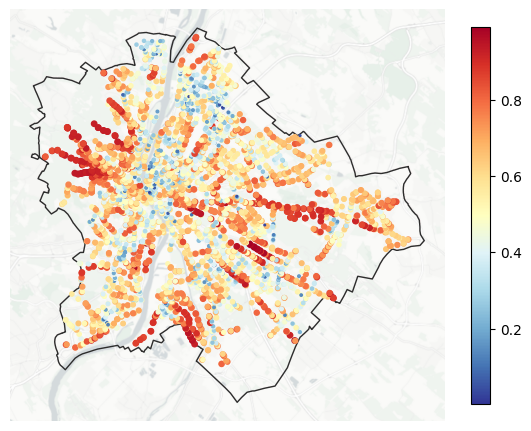

In [12]:
to_plot_el = stops.merge(ellipticity, on="stop_id", how="left").sort_values(
    "ellipticity", ascending=True
)
fig, ax = plt.subplots(figsize=(7, 7))
bp.plot(ax=ax, fc="none", ec="#2d2d2d")
gpd.clip(to_plot_el, bp_area).plot(
    column="ellipticity",
    legend=True,
    legend_kwds={"shrink": 0.7},
    markersize=minmax_scale(
        gpd.clip(to_plot_el, bp_area)["ellipticity"], feature_range=(1, 16)
    ),
    # cmap="PiYG_r",
    cmap="RdYlBu_r",
    ax=ax,
)
cx.add_basemap(
    ax,
    crs=23700,
    source=cx.providers.CartoDB.PositronNoLabels,
    alpha=1,
    attribution=False,
)
ax.axis("off")
ax.margins(0)
# for i in ["png", "pdf"]:
#     fig.savefig(
#         f"../abstract/figures/ellipticity_40.{i}",
#         dpi=300,
#         facecolor="white",
#         bbox_inches="tight",
#         pad_inches=0.1,
#         metadata=metadata,
#     )

In [13]:
ellipticity[ellipticity["ellipticity"]>0.8]

,stop_id,ellipticity
0,007877,0.9241
1,007878,0.8772
10,007913,0.8776
11,007914,0.8842
15,007927,0.8077
...,...,...
4421,F04552,0.8070
4423,F04554,0.8384
4425,F04556,0.8428
4427,F04558,0.8223


In [12]:
bins = jenkspy.jenks_breaks(
    to_plot_el.query("ellipticity.notna()")["ellipticity"], n_classes=6
)
bins

[0.0099, 0.1877, 0.3003, 0.4071, 0.5142, 0.6339, 0.9014]

In [14]:
to_plot_el.query("stop_name=='509. utca' & ellipticity.notna()")

,stop_id,stop_name,stop_lat,stop_lon,stop_code,location_type,parent_station,wheelchair_boarding,stop_direction,clust,max_distance,quant,geometry,ellipticity
5433,011715,509. utca,47.484963,19.225442,None,NaN,011715,2.0,-79.0,2081,104.07464,3,POINT (663414.099 237906.185),0.6109


In [ ]:
to_plot_el.query("stop_name=='Jászai Mari tér'")["stop_id"]

,stop_id,stop_name,stop_lat,stop_lon,clust,Node,Eigenvector Centrality,Degree Centrality,Closeness Centrality,Betweenness Centrality,geometry,ellipticity
2701,F02511,Jászai Mari tér,47.513890,19.049372,321,321.0,0.000003,0.000492,0.065604,0.000000,POINT (650145.183 241107.076),0.0442
1505,F00929,Jászai Mari tér,47.512532,19.050115,322,322.0,0.000710,0.002459,0.087784,0.045095,POINT (650201.149 240956.1),0.1426
1506,F00930,Jászai Mari tér,47.512478,19.049558,322,322.0,0.000710,0.002459,0.087784,0.045095,POINT (650159.195 240950.096),0.3354
134,008455,Jászai Mari tér,47.512811,19.047938,320,320.0,0.000394,0.001476,0.086108,0.000842,POINT (650037.173 240987.117),0.4419
1504,F00926,Jászai Mari tér,47.512847,19.048841,320,320.0,0.000394,0.001476,0.086108,0.000842,POINT (650105.188 240991.119),0.4821
1503,F00925,Jászai Mari tér,47.513099,19.048177,320,320.0,0.000394,0.001476,0.086108,0.000842,POINT (650055.175 241019.136),0.4840


In [14]:
to_plot_el.query("ellipticity > 0.8")

,stop_id,stop_name,stop_lat,stop_lon,stop_code,location_type,parent_station,wheelchair_boarding,stop_direction,clust,max_distance,quant,geometry,ellipticity
394,050187,"Vecsés, Fő út",47.418379,19.249419,None,NaN,050187,2.0,116.0,1963,0.000000,1,POINT (665240.058 230508.168),0.8019
453,F04785,Ady Endre utca,47.575887,18.891140,None,NaN,F04785,2.0,105.0,2211,0.000000,1,POINT (638240.990 248011.640),0.8350
5693,F04828,"Nagykovácsi, községháza",47.575922,18.884401,None,NaN,F04828,1.0,77.0,2207,31.397907,2,POINT (637734.009 248016.575),0.8638
451,F04826,Diófa utca (Posta),47.575818,18.886794,None,NaN,F04826,2.0,65.0,2208,0.000000,1,POINT (637914.016 248004.637),0.8638
6049,CSF04627,Szigetcsép,47.270213,18.956230,CSF04627,1.0,CSF04627,NaN,NaN,2420,63.101021,4,POINT (643097.691 214021.063),0.8701
5741,CSF04611,Szigetszentmiklós,47.344121,19.050215,CSF04611,1.0,CSF04611,NaN,NaN,2242,19.428637,3,POINT (650209.074 222233.290),0.8860
452,031884,"Nagykovácsi, Tisza István tér",47.575789,18.879511,None,NaN,031884,1.0,NaN,2209,0.000000,1,POINT (637366.093 248002.572),0.8875
454,F04825,Diófa utca (Posta),47.576253,18.889358,None,NaN,F04825,2.0,-96.0,2212,0.000000,1,POINT (638107.009 248052.603),0.8875
5755,CSF04613,József Attila-telep,47.337122,19.034441,CSF04613,1.0,CSF04613,NaN,NaN,2252,17.039283,3,POINT (649017.021 221455.300),0.8950
455,F04786,Ady Endre utca,47.575359,18.893082,None,NaN,F04786,2.0,-40.0,2213,0.000000,1,POINT (638386.973 247952.646),0.8962


In [24]:
def plot(
    accessibility_area: Polygon,
    stops: gpd.GeoDataFrame,
    walk_area: Optional[gpd.GeoDataFrame] = None,
    bike_area: Optional[gpd.GeoDataFrame] = None,
    display_legend: bool = True,
    accessibility_color: str = colors[1],
) -> tuple[plt.Figure, plt.Axes]:
    aa = accessibility_area
    ncols = 2
    if walk_area is not None:
        aa = accessibility_area.difference(walk_area.geometry.tolist()[0])
        ncols = 3
    if bike_area is not None:
        aa = accessibility_area.difference(bike_area.geometry.tolist()[0])
        ncols = 2
    fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")
    gpd.GeoDataFrame(geometry=[aa], crs=23700).plot(
        ax=ax,
        zorder=10,
        ec=accessibility_color,
        fc=accessibility_color + "70",
        lw=2,
    )
    if bike_area is not None:
        ba = bike_area.difference(walk_area.geometry.tolist()[0])
        ba.plot(ax=ax, zorder=20, ec=colors[5], fc=colors[5] + "70", lw=2)
    if walk_area is not None:
        walk_area.plot(ax=ax, zorder=30, ec=colors[3], fc=colors[3] + "70", lw=2)
    stops.plot(
        ax=ax,
        zorder=30,
        color="k",
        markersize=10,
    )
    cx.add_basemap(
        ax,
        crs=23700,
        source=cx.providers.CartoDB.VoyagerNoLabels,
        alpha=1,
        attribution=False,
    )
    ax.axis("off")
    ax.margins(0)
    legend_elements = []
    if walk_area is not None:
        elem_walk = Patch(
            facecolor=colors[3] + "70", edgecolor=colors[3], label="walk 15 minute"
        )
        legend_elements.append(elem_walk)
    if bike_area is not None:
        elem_bike = Patch(
            facecolor=colors[5] + "70", edgecolor=colors[5], label="bicycle 10 minute"
        )
        legend_elements.append(elem_bike)
    elem_pubt = Patch(
        facecolor=accessibility_color + "70",
        edgecolor=accessibility_color,
        label="public transport net 10 minute",
    )
    legend_elements.append(elem_pubt)
    stop = Line2D(
        [0], [0], color="#2d2d2d", lw=4, linestyle="none", marker="o", label="stop"
    )
    if display_legend:
        legend_elements.append(stop)
        legend = ax.legend(handles=legend_elements, ncols=ncols, loc="upper center")
        legend.set_zorder(100)
    return fig, ax

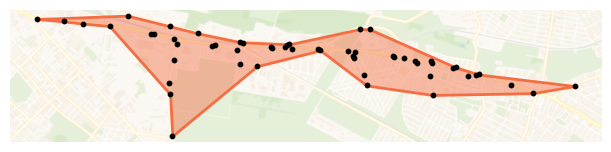

In [32]:
STOP = "F01006"  # Kálvin
STOP = "011715"  # 509. utca
points_10m = stops[stops["stop_id"].isin(accessible_stops[STOP])].union_all()
cv_accessibility_10m = convex_hull(points_10m)
cc_accessibility_10m = concave_hull(points_10m, ratio=0.3)

fig, ax = plot(
    cc_accessibility_10m,
    stops[stops["stop_id"].isin(accessible_stops[STOP])],
    # walk,
    display_legend=False,
    accessibility_color="#f46d43",
)
# ax.set_ylim([234650, 243200])
# for i in ["png", "pdf", "svg"]:
#     fig.savefig(
#         f"../abstract/figures/509_accessibility_area.{i}",
#         dpi=300,
#         facecolor="white",
#         bbox_inches="tight",
#         pad_inches=0,
#         metadata=metadata,
#     )

{}

In [52]:
result = []
for i in stops_cluster:
    result += accessible_stops[i]

In [53]:
len(result)

455

In [54]:
len(set(result))

193

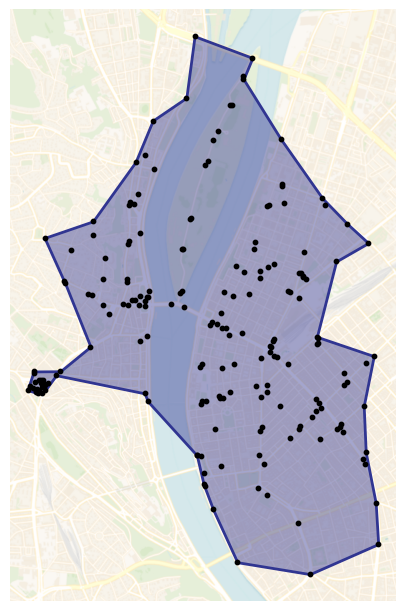

In [57]:
STOP = "CSLM4FT1"  # Fővám tér
STOP = "F01023"  # Nyugati 1
STOP = "F00929"  # Nyugati 1
points_10m = stops[stops["stop_id"].isin(accessible_stops[STOP])].union_all()
points_10m = stops[stops["stop_id"].isin(set(result))].union_all()
cv_accessibility_10m = convex_hull(points_10m)
cc_accessibility_10m = concave_hull(points_10m, ratio=0.3)

fig, ax = plot(
    cc_accessibility_10m,
    stops[stops["stop_id"].isin(set(result))],
    display_legend=False,
    accessibility_color="#303591",
)
# for i in ["png", "pdf", "svg"]:
#     fig.savefig(
#         f"../abstract/figures/fovam_accessibility_area.{i}",
#         dpi=300,
#         facecolor="white",
#         bbox_inches="tight",
#         pad_inches=0,
#         metadata=metadata,
#     )

(640750.0, 675750.0, 221000.0, 256000.0)

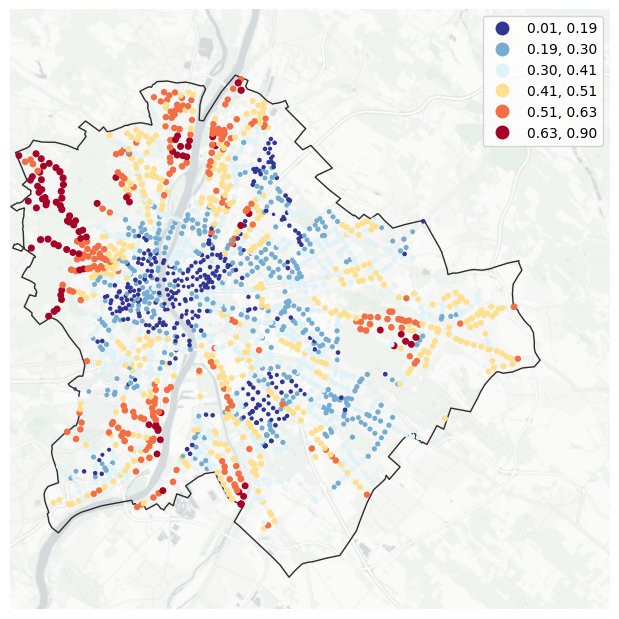

In [12]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0, 0, 1, 1], frameon=False, xticks=[], yticks=[])
ax.set_ylim([221000, 256000])
ax.set_xlim([640750, 675750])
bp.plot(ax=ax, fc="none", ec="#2d2d2d")
gpd.clip(to_plot_el, bp_area).query("ellipticity.notna()").plot(
    column="ellipticity",
    legend=True,
    cmap="RdYlBu_r",
    ax=ax,
    scheme="UserDefined",
    classification_kwds=dict(
        bins=bins[1:],
    ),
    markersize=minmax_scale(
        gpd.clip(to_plot_el, bp_area).query("ellipticity.notna()")["ellipticity"],
        feature_range=(2, 18),
    ),
)
cx.add_basemap(
    ax,
    crs=23700,
    source=cx.providers.CartoDB.PositronNoLabels,
    alpha=1,
    attribution=False,
)
ax.margins(0)
ax.axis("off")
# for i in ["png", "pdf"]:
#     fig.savefig(
#         f"../abstract/figures/ellipticity_40_jenks.{i}",
#         dpi=300,
#         facecolor="white",
#         bbox_inches="tight",
#         pad_inches=0,
#         metadata=metadata,
#     )